# Task 5
## Final Model: Hyperparameter Selection, Training, and SHAP Interpretation


In [ ]:
#Libraries & Path
DATA_PATH = '../data/students_dataset.csv'
##########################
import random, os, warnings, sys, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
warnings.filterwarnings('ignore')
sys.path.insert(0, '../src')
from script import *
sns.set_theme(style='whitegrid', font_scale=1.1)
##########################
# Load winner
with open('../results/winner.json') as f:
    WINNER = json.load(f)['winner']
print(f'Winner: {WINNER}')
##########################
# Instantiate winner classifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB

Winner: LDA


## Load Dataset

In [2]:
df_raw = pd.read_csv(DATA_PATH) 
df = df_raw.copy()
df['num'] = (df['num'] > 0).astype(int)  
X = df.drop(columns='num')
y = df['num']

---

## Select Best Hyperparameters via 5-Fold CV on Full Data

In [15]:
RESULTS_DIR = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

WINNER = "LDA"
base_clf = LinearDiscriminantAnalysis()

# Hyperparameter space for the winner model
# Same logic as used in Task 3
def winner_param_space(trial):
    solver = trial.suggest_categorical("solver", ["lsqr", "eigen"])
    return {
        "solver": solver,
        "shrinkage": trial.suggest_float("shrinkage", 0.0, 1.0),
    }

def objective(trial):
    params = winner_param_space(trial)
    candidate = clone(base_clf).set_params(**params)
    
    pipe = Pipeline([ ("preprocessor", build_preprocessor()),("clf", candidate)])
    # Simple stratified 5-fold CV on the full dataset
    cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
    scores = cross_val_score(pipe,X,y,cv=cv,scoring="roc_auc",n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=SEED))

study.optimize(objective,n_trials=100, show_progress_bar=True)

best_params = study.best_params

print(f"Winner algorithm: {WINNER}")
print(f"Best hyperparameters: {best_params}")
print(f"Best 5-fold CV AUC: {study.best_value:.4f}")

# Save final hyperparameters for final model training
with open(RESULTS_DIR / "best_hyperparams.json", "w") as f:
    json.dump({"winner": WINNER, "best_params": best_params,"best_cv_auc": study.best_value},f,indent=2)

print(f"Best hyperparameters saved to {RESULTS_DIR / 'best_hyperparams.json'}")

  0%|          | 0/100 [00:00<?, ?it/s]

Winner algorithm: LDA
Best hyperparameters: {'solver': 'lsqr', 'shrinkage': 0.33127303180847645}
Best 5-fold CV AUC: 0.9058
Best hyperparameters saved to ..\results\best_hyperparams.json


**Comment:** 

- Simple stratified 5-fold cross-validation was performed on the full dataset —> Selection of the best hyperparameters for the previously selected winner algorithm. 

- Same logic with Task 3 —> same Optuna hyperparameter search space reused to keep the final tuning procedure consistent with the repeated nested cross-validation analysis. 

- ROC-AUC was used as the optimization metric, and the best hyperparameters were saved for training the final model.

## Train Final Model on All Data


In [17]:
final_clf = clone(base_clf).set_params(**best_params)

final_pipeline = Pipeline([('preprocessor', build_preprocessor()),('clf', final_clf),])

final_pipeline.fit(X, y)
print('Final model trained on all data.')

# Saving complete pipeline
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)
model_path = models_dir / 'final_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(final_pipeline, f)
print(f'Final model saved.')

# Verify it loads and predicts correctly (two final opposite)
with open(model_path, 'rb') as f:
    loaded_model = pickle.load(f)

test_pred = loaded_model.predict(X.iloc[:10])
print(f'Smoke-test predictions on first 10 samples: {test_pred}')

Final model trained on all data.
Final model saved.
Smoke-test predictions on first 10 samples: [1 0 0 0 1 1 1 1 0 1]


## SHAP Interpretation


In [ ]:
# Since the selected winner model was LDA, SHAP values were computed using `LinearExplainer`, appropriate approach for linear models.
import shap
preprocessor = final_pipeline.named_steps["preprocessor"]
clf = final_pipeline.named_steps["clf"]
X_preprocessed = preprocessor.transform(X)
feature_names_preprocessed = preprocessor.get_feature_names_out()

X_pp_df = pd.DataFrame( X_preprocessed, columns=feature_names_preprocessed)

# SHAP interpretation for the final LDA model
explainer = shap.LinearExplainer(clf, X_pp_df)
shap_vals = explainer.shap_values(X_pp_df)

print(f"SHAP values shape: {shap_vals.shape}")
print(f"Preprocessed feature matrix shape: {X_pp_df.shape}")

SHAP values shape: (242, 20)
Preprocessed feature matrix shape: (242, 20)


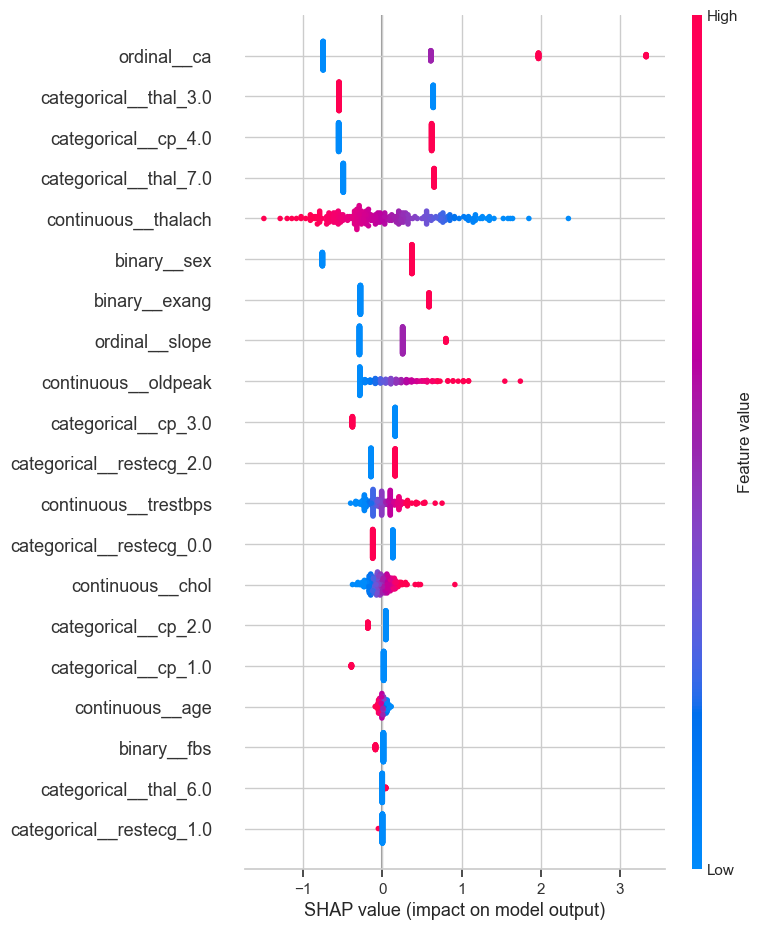

In [20]:
#  SHAP Summary (Beeswarm) 
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_vals, X_pp_df, show=False)
plt.savefig("../figures/shap_beeswarm.png", bbox_inches="tight", dpi=150)
plt.show()



**Comment:** The SHAP plot indicates that the final LDA model seems to be mainly driven by `ca`, `thal`, `cp`, `thalach`, `exang`, `slope`, and `oldpeak`.

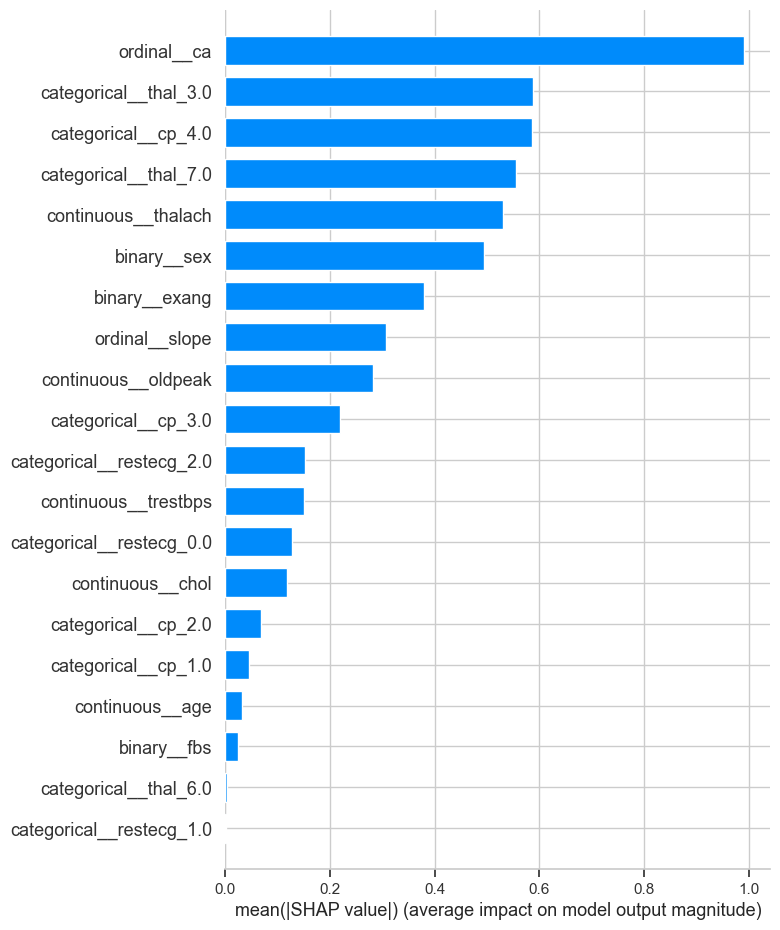

In [21]:
# SHAP Bar Plot (Mean- SHAP) 
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_vals, X_pp_df, plot_type='bar', show=False)
plt.savefig('../figures/shap_bar.png', bbox_inches='tight', dpi=150)
plt.show()

**Interpretation**: The mean absolute SHAP plot confirms that `ca` has the strongest average impact on the final LDA model output.